In [1]:
from sklearn.calibration import calibration_curve
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
def plot_aligned_calibration_boxplot(df, score_col='prob', 
                                   prediction_col='prediction',
                                   gold_standard_col='ground_truth', 
                                   n_bins=10, min_samples=5, model_type=" ", filename=None):
    """
    Plot unified calibration boxplot with properly aligned x-axis scales.
    Stratifies by CANCER_TYPE - each point represents one cancer type's performance.
    
    Parameters:
    - df: pandas DataFrame
    - score_col: column with confidence scores
    - prediction_col: column with predicted classes
    - gold_standard_col: column with true classes
    - n_bins: number of probability bins
    - min_samples: minimum samples required per bin (default: 5)
    """
    # Create a copy to avoid modifying original dataframe
    df_plot = df.copy()
    
    # Drop rows with missing values in relevant columns
    df_plot = df_plot.dropna(subset=[score_col, prediction_col, gold_standard_col, 'CANCER_TYPE'])
    
    # Add binary correct/incorrect indicator
    df_plot['correct'] = (df_plot[prediction_col] == df_plot[gold_standard_col]).astype(int)
    
    # Create numeric bins first for proper alignment
    df_plot['prob_bin_num'] = pd.cut(df_plot[score_col], bins=n_bins, 
                                    include_lowest=True)
    
    # Calculate positive rates (accuracy) within each bin for each CANCER_TYPE
    # This stratifies by cancer type so each point represents one cancer type's performance
    bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(
        ['mean', 'count']).reset_index()
    bin_stats.rename(columns={'mean': 'observed_frac'}, inplace=True)
    
    # Filter out bins with too few samples
    bin_stats = bin_stats[bin_stats['count'] >= min_samples]
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    
    # Prepare data for boxplots - create ALL bins (0 to n_bins-1)
    boxplot_data = []
    positions = []
    valid_bins = []
    
    # Get all bin intervals from the categorical
    all_bin_intervals = df_plot['prob_bin_num'].cat.categories
    
    for i, bin_interval in enumerate(all_bin_intervals):
        bin_data = bin_stats[bin_stats['prob_bin_num'] == bin_interval]['observed_frac']
        if len(bin_data) > 0:
            boxplot_data.append(bin_data.values)
        else:
            # Empty bin - add None to maintain position
            boxplot_data.append([])
        
        # Use evenly spaced positions (0.05, 0.15, 0.25, ..., 0.95)
        positions.append((i + 0.5) / n_bins)
        
        # Format bin labels to clean intervals like 0.0-0.1, 0.1-0.2, etc.
        left = i / n_bins
        right = (i + 1) / n_bins
        valid_bins.append(f'{left:.1f}-{right:.1f}')
    
    # Filter out empty bins for plotting
    non_empty_data = []
    non_empty_positions = []
    non_empty_labels = []
    
    for data, pos, label in zip(boxplot_data, positions, valid_bins):
        if len(data) > 0:
            non_empty_data.append(data)
            non_empty_positions.append(pos)
            non_empty_labels.append(label)
    
    # Create boxplots at correct x positions
    if non_empty_data:
        boxplot = plt.boxplot(non_empty_data, 
                             positions=non_empty_positions, 
                             widths=0.08,  # Fixed width for consistent appearance
                             patch_artist=True)
        
        # Style the boxes and ensure minimum visible width
        for i, box in enumerate(boxplot['boxes']):
            box.set(facecolor='lightblue', alpha=0.7)
            # Get the box vertices
            path = box.get_path()
            vertices = path.vertices
            
            # Calculate the vertical extent of the box (Q1 to Q3)
            y_values = vertices[:, 1]
            q1 = min(y_values)
            q3 = max(y_values)
            box_height = q3 - q1
            
            # If box height is too small, add a minimum height
            min_box_height = 0.02  # Minimum visible height on the plot
            if box_height < min_box_height:
                # Center the minimum box around the median
                median_y = (q1 + q3) / 2
                new_q1 = median_y - min_box_height / 2
                new_q3 = median_y + min_box_height / 2
                
                # Update vertices to new height
                vertices[0, 1] = new_q1  # bottom left
                vertices[1, 1] = new_q1  # bottom right
                vertices[2, 1] = new_q3  # top right
                vertices[3, 1] = new_q3  # top left
                vertices[4, 1] = new_q1  # closing point
        
        # Add overlaying dots for all samples
        for i, (bin_interval, pos) in enumerate(zip([interval for interval in all_bin_intervals if len(bin_stats[bin_stats['prob_bin_num'] == interval]['observed_frac']) > 0], non_empty_positions)):
            bin_data = bin_stats[bin_stats['prob_bin_num'] == bin_interval]['observed_frac'].values
            # Add small random jitter to x position for visibility
            x_jitter = np.random.normal(pos, 0.01, size=len(bin_data))
            plt.scatter(x_jitter, bin_data, alpha=0.4, s=30, c='darkblue', edgecolors='black', linewidth=0.5, zorder=3)
    
    # Perfect calibration line - now properly aligned
    x_perfect = np.linspace(0, 1, 100)
    plt.plot(x_perfect, x_perfect, 'r--', label='Perfect calibration', linewidth=2)
    
    # Formatting
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    # Use ALL positions and labels for x-axis ticks (evenly distributed)
    plt.xticks(positions, valid_bins, rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Predicted probability bin', fontsize=20)
    plt.ylabel('Observed fraction correct', fontsize=20)
    plt.legend(loc='best', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if filename != None:
        plt.savefig(filename, dpi=500, bbox_inches='tight')
    plt.show()

## Load mutation status prediction results

In [3]:
"""Load and prepare the mutation status data for analysis."""

# Configuration
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_final"
SAMPLE_TSVS = [
    '/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',
    '/data1/morrisq/yuj13/llm_genomics/msk_ch_2023/data_clinical_sample.txt'
]
MODEL_NAMES = ["gpt-5", "o3-mini", "gpt-4o", "medgemma", "qwen3", "claude-sonnet-37", "claude-opus-45", "deepseek", "MetaCH"]

# Helper functions
def build_sampleid_to_cancer(sample_tsvs):
    """Build mapping from SAMPLE_ID to CANCER_TYPE from clinical data."""
    samp2ct = {}
    for tsv_path in sample_tsvs:
        df_temp = pd.read_csv(tsv_path, sep='\t', comment='#')
        for _, row in df_temp.iterrows():
            samp2ct[row['SAMPLE_ID']] = row.get('CANCER_TYPE', 'UNKNOWN')
    return samp2ct

def load_all_model_predictions(model_dirs, model_names, samp2ct, ground_truth_label='ground_truth'):
    """Load predictions from all models and merge into single dataframe."""
    merged = None
    
    for model_dir, model_name in zip(model_dirs, model_names):
        csv_files = glob.glob(os.path.join(model_dir, "*.csv"))
        if not csv_files:
            print(f"Warning: No CSV files found for {model_name}")
            continue
        
        df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
        
        # Add CANCER_TYPE from sample mapping
        df['CANCER_TYPE'] = df['SAMPLE_ID'].map(samp2ct)
        
        if merged is None:
            # First model: initialize merged dataframe
            merged = df[['SAMPLE_ID', 'CANCER_TYPE']].copy()
            # Rename the label column to 'ground_truth' if present
            if ground_truth_label in df.columns:
                merged['ground_truth'] = df[ground_truth_label]
            elif 'label' in df.columns:
                merged['ground_truth'] = df['label']
        
        # Add model-specific prediction and probability columns
        if 'prediction' in df.columns:
            merged[f'{model_name}_pred'] = df['prediction']
        if 'prob' in df.columns:
            merged[f'{model_name}_prob'] = df['prob']
    
    return merged

# Load data
print("Building sample-to-cancer mapping...")
samp2ct = build_sampleid_to_cancer(SAMPLE_TSVS)

print("Loading model predictions...")
MODEL_DIRS = [os.path.join(BASE_RESULTS_DIR, model) for model in MODEL_NAMES]
merged_predictions = load_all_model_predictions(MODEL_DIRS, MODEL_NAMES, samp2ct, ground_truth_label='ground_truth')

# Drop rows with UNKNOWN or ERROR
print(f"Total samples before filtering: {len(merged_predictions)}")
for col in merged_predictions.columns:
    if '_pred' in col:
        merged_predictions = merged_predictions[
            (~merged_predictions[col].astype(str).str.contains('UNKNOWN', case=False, na=False)) &
            (~merged_predictions[col].astype(str).str.contains('ERROR', case=False, na=False))
        ]
print(f"Total samples after filtering: {len(merged_predictions)}")

print(f"\nDataframe shape: {merged_predictions.shape}")
print(f"\nColumns: {merged_predictions.columns.tolist()}")
print(f"\nGround truth classes: {merged_predictions['ground_truth'].unique()}")

Building sample-to-cancer mapping...
Loading model predictions...
Total samples before filtering: 224475
Total samples after filtering: 224361

Dataframe shape: (224361, 21)

Columns: ['SAMPLE_ID', 'CANCER_TYPE', 'ground_truth', 'gpt-5_pred', 'gpt-5_prob', 'o3-mini_pred', 'o3-mini_prob', 'gpt-4o_pred', 'gpt-4o_prob', 'medgemma_pred', 'medgemma_prob', 'qwen3_pred', 'qwen3_prob', 'claude-sonnet-37_pred', 'claude-sonnet-37_prob', 'claude-opus-45_pred', 'claude-opus-45_prob', 'deepseek_pred', 'deepseek_prob', 'MetaCH_pred', 'MetaCH_prob']

Ground truth classes: ['TUMOR-SOMATIC' 'CHIP']


## Generate calibration curves for all models


Generating calibration curve for gpt-5...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


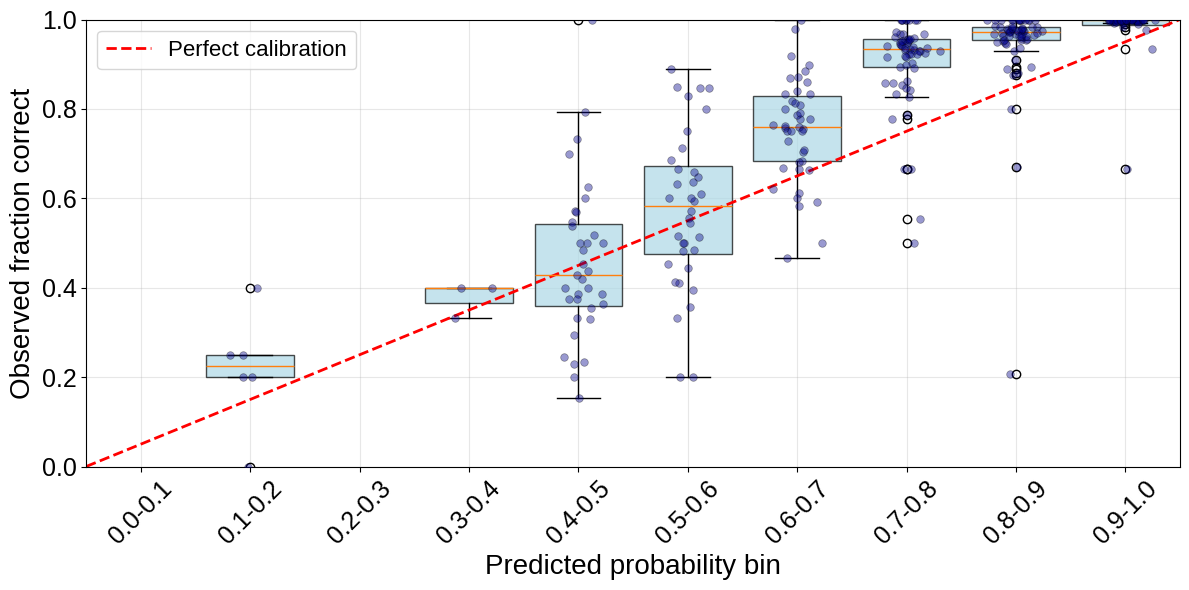


Generating calibration curve for o3-mini...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


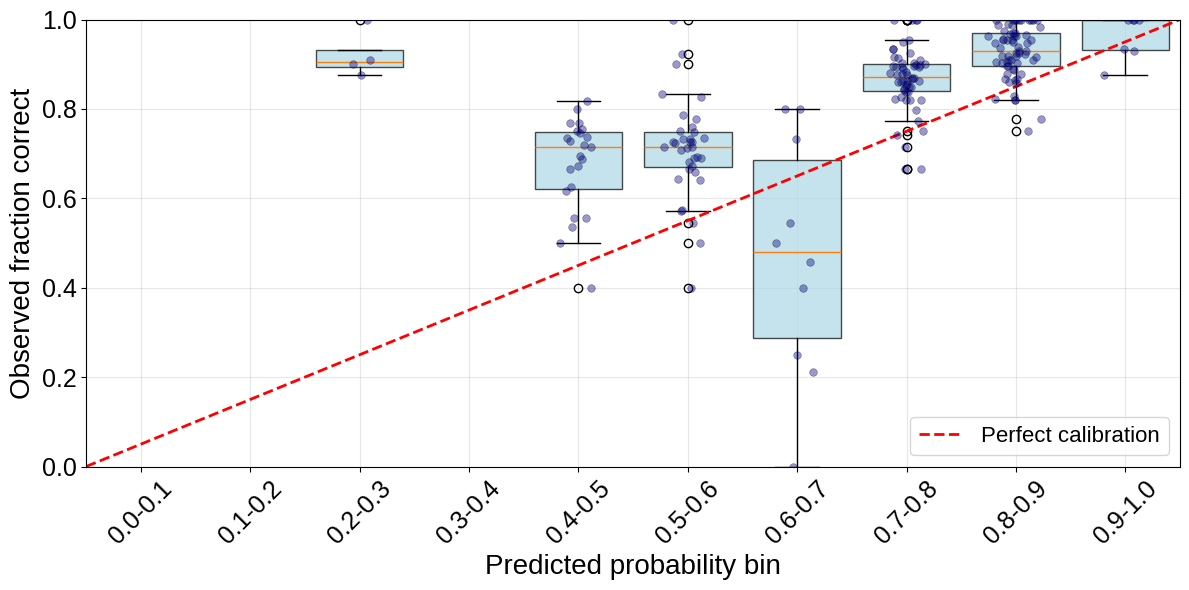


Generating calibration curve for gpt-4o...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


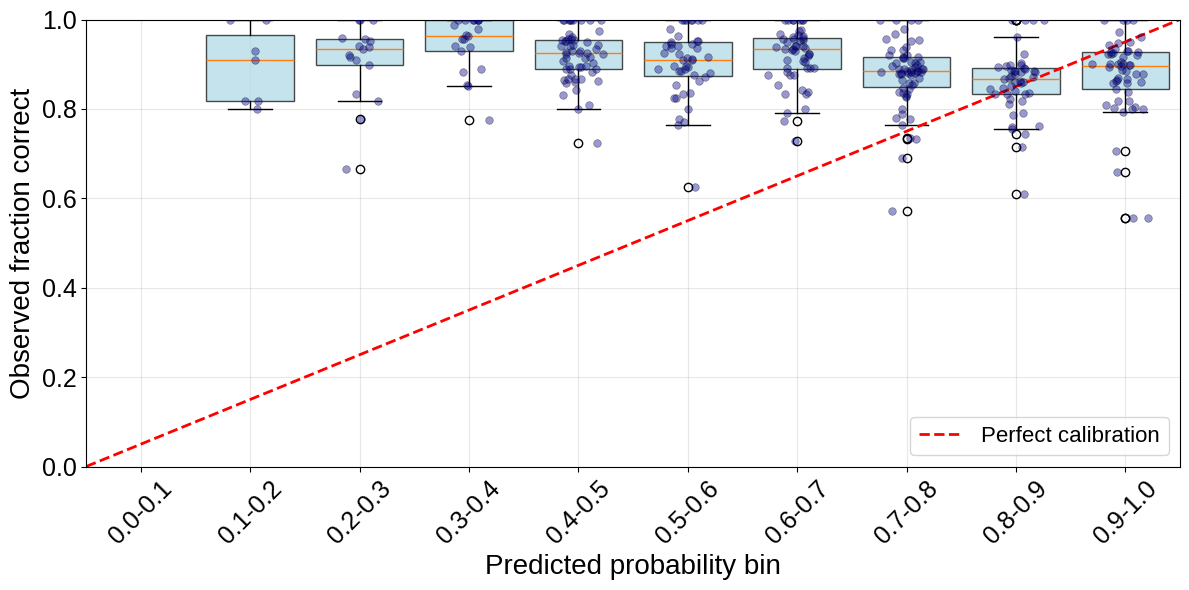


Generating calibration curve for medgemma...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


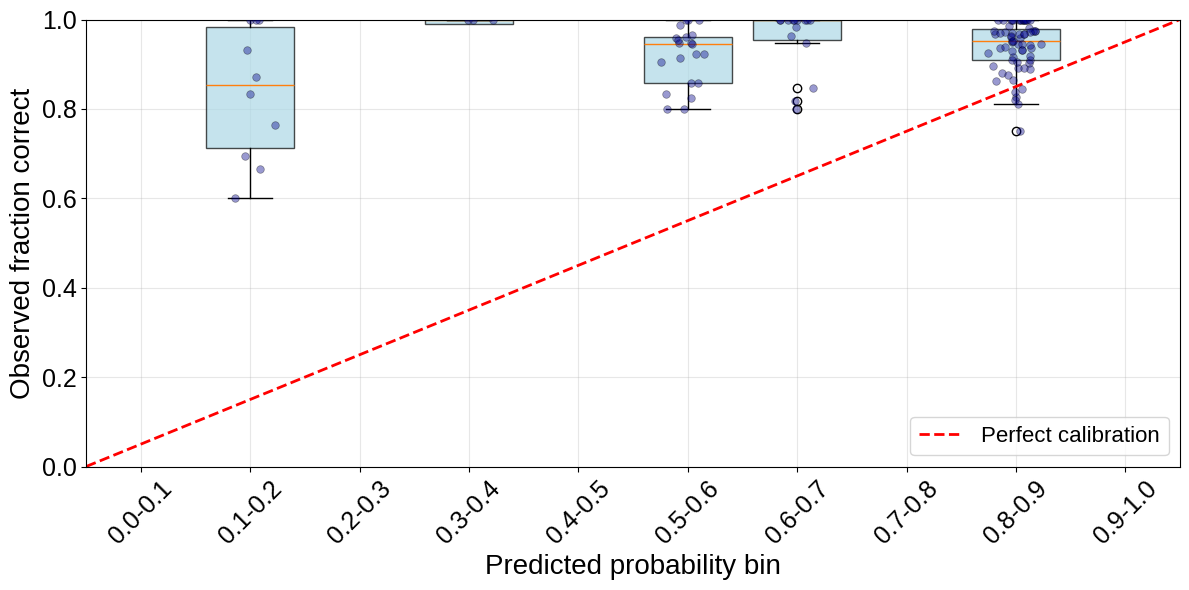


Generating calibration curve for qwen3...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


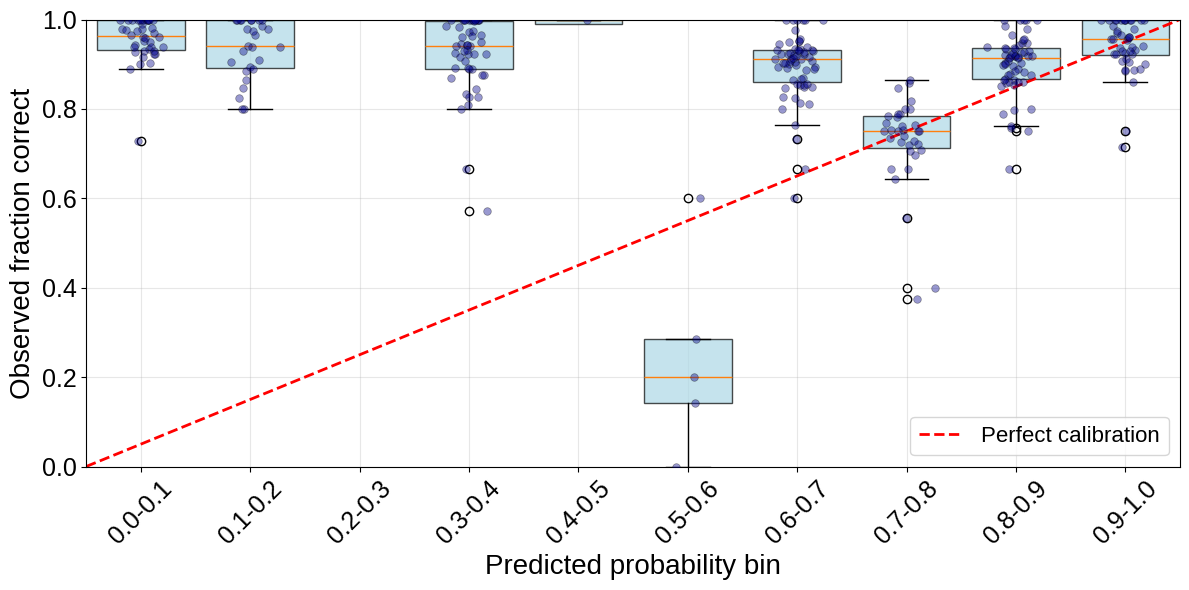


Generating calibration curve for claude-sonnet-37...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


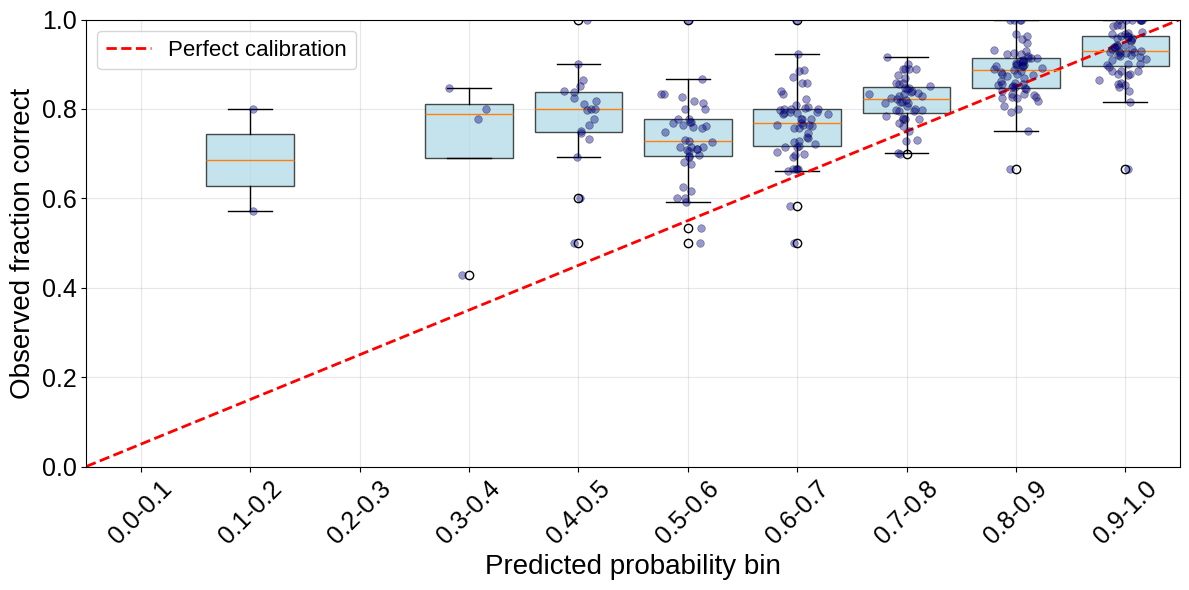


Generating calibration curve for claude-opus-45...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


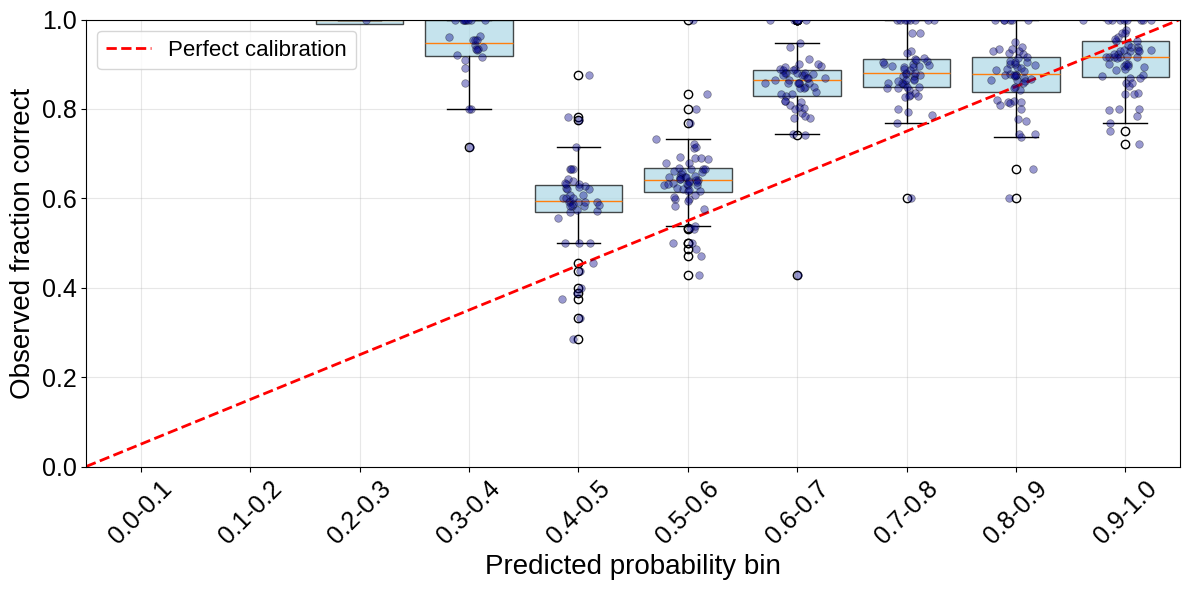


Generating calibration curve for deepseek...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


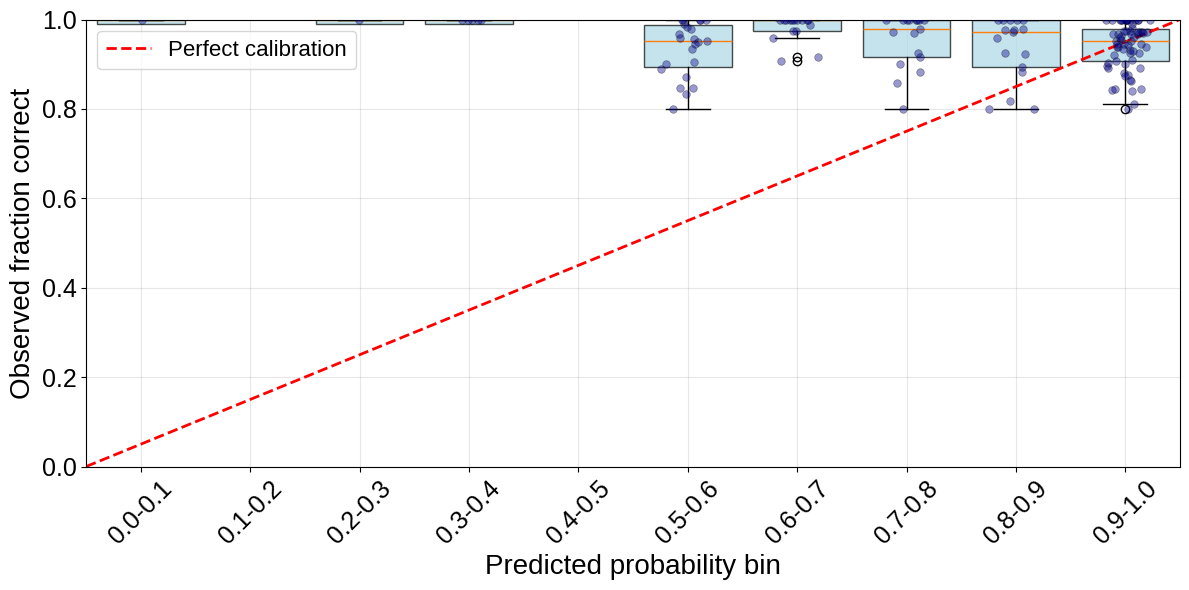


Generating calibration curve for MetaCH...


/tmp/ipykernel_1604835/1969333097.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', 'CANCER_TYPE'])['correct'].agg(


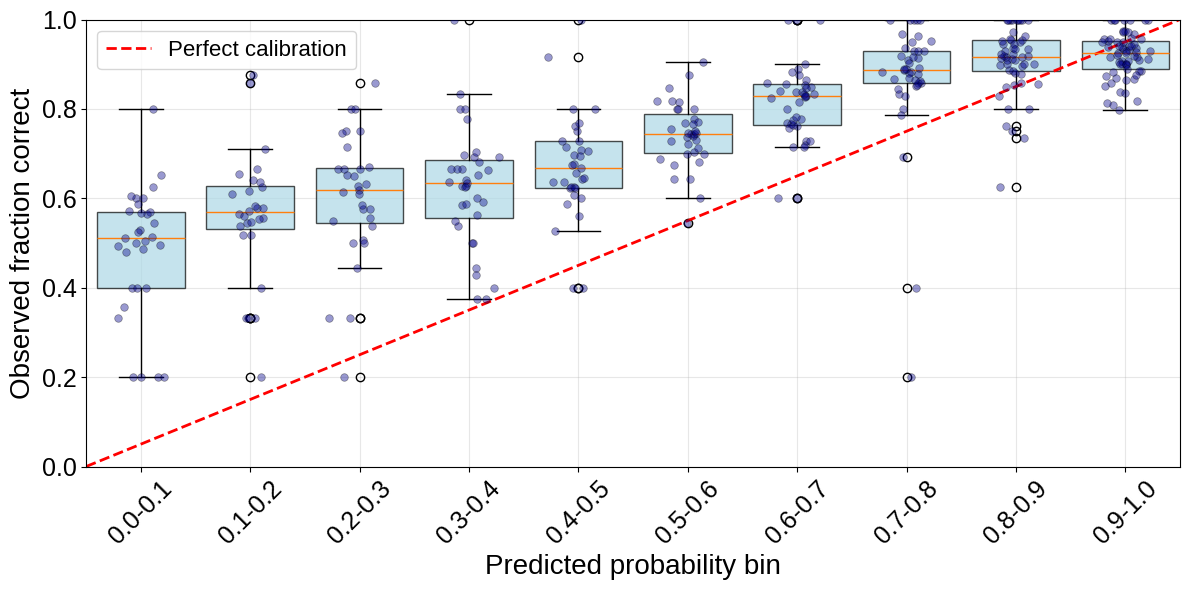

In [4]:
"""Generate calibration curves for each model."""

for model_name in MODEL_NAMES:
    pred_col = f'{model_name}_pred'
    prob_col = f'{model_name}_prob'
    
    if pred_col in merged_predictions.columns and prob_col in merged_predictions.columns:
        print(f"\nGenerating calibration curve for {model_name}...")
        plot_aligned_calibration_boxplot(
            merged_predictions,
            score_col=prob_col,
            prediction_col=pred_col,
            gold_standard_col='ground_truth',
            n_bins=10,
            min_samples=5,
            model_type=model_name,
            filename=f"{model_name}_calibration_curve.pdf"
        )
    else:
        print(f"Warning: Missing prediction or probability columns for {model_name}")